Mean Squared Error: 0.4944244179351423


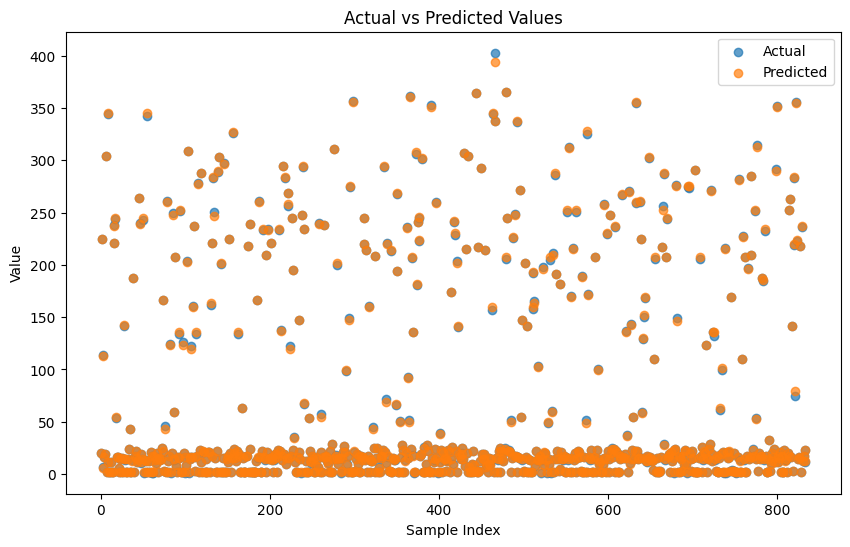

In [ ]:
import pandas as pd
from datasets import load_dataset

# Load dataset
tesla = load_dataset('codesignal/tsla-historic-prices')
tesla_df = pd.DataFrame(tesla['train'])

tesla_df['Date'] = pd.to_datetime(tesla_df['Date'])
tesla_df.set_index('Date', inplace=True)

# Feature Engineering
tesla_df['SMA_5'] = tesla_df['Adj Close'].rolling(window=5).mean()
tesla_df['SMA_10'] = tesla_df['Adj Close'].rolling(window=10).mean()
tesla_df['EMA_5'] = tesla_df['Adj Close'].ewm(span=5, adjust=False).mean()
tesla_df['EMA_10'] = tesla_df['Adj Close'].ewm(span=10, adjust=False).mean()
tesla_df['High-Low'] = tesla_df['High'] - tesla_df['Low']
tesla_df['Price-Open'] = tesla_df['Close'] - tesla_df['Open']
tesla_df['Close_Lag_1'] = tesla_df['Adj Close'].shift(1)

# Drop NaN values created by moving averages
tesla_df.dropna(inplace=True)

# Select features and target
features = tesla_df[['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_5', 'SMA_10', 'EMA_5', 'EMA_10']].values
target = tesla_df['Adj Close'].shift(-1).dropna().values  # Predicting next day's close price


# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.25, random_state=42)

